In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('salmo'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
import os
import zipfile

path = r"C:\Users\shubh\Downloads\poultry_diseases"

# for dirname, _, filenames in os.walk(path):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
zip_path = r"C:\Users\shubh\Downloads\poultry_diseases.zip"

# Folder where you want to extract
extract_path = r"C:\Users\shubh\Downloads\poultry_diseases"

# ✅ Extract the zip file (only once is enough)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
for dirname, _, filenames in os.walk(extract_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.0.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.10.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.100.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1000.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1001.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1002.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1003.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1004.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1005.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1006.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1007.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1008.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1009.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.101.jpg
C:\Users\shubh\Downloads\poultry_diseases\cocci\cocci.1010.jpg
C:

In [2]:
import numpy as np
import pathlib
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
directory = "C:/Users/shubh/Downloads/poultry_diseases"
dir=os.listdir(directory)
dir

['cocci', 'healthy', 'ncd', 'salmo']

In [4]:
# variables to use
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3

In [5]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,)

Found 6812 files belonging to 4 classes.


In [6]:
class_names=dataset.class_names

Visualizing random images from the dataset¶

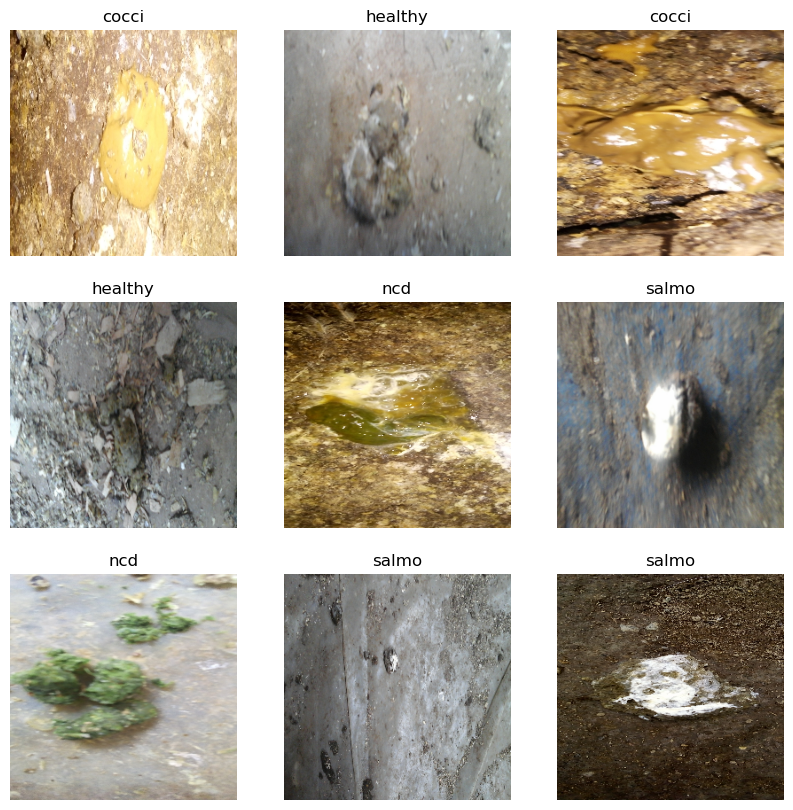

In [8]:
plt.figure(figsize=(10,10))
for img,label in dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_names[label[i].numpy()])
        plt.axis("off")

Splitting the data into train,test and validation data¶

In [35]:
# def data_split(data,train_size=0.8,validation_size=0.1,test_size=0.1,shuffle=True):
#     if shuffle:
#         data.shuffle(100,seed=0)
#     train_set=data.take(int(len(data)*train_size))
#     val_set=data.skip(len(train_set)).take(int(len(data)*validation_size))
#     test_set=data.skip(len(train_set)+len(val_set))
#     return train_set, val_set, test_set

# def data_split(dataset, train_size=0.8, validation_size=0.1, test_size=0.1, shuffle=True):
#     if shuffle:
#         dataset = dataset.shuffle(buffer_size=100, seed=0)

#     total_batches = tf.data.experimental.cardinality(dataset).numpy()
#     train_batches = int(total_batches * train_size)
#     val_batches = int(total_batches * validation_size)
    
#     train_set = dataset.take(train_batches)
#     val_set = dataset.skip(train_batches).take(val_batches)
#     test_set = dataset.skip(train_batches + val_batches)
    
#     return train_set, val_set, test_set

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 6812 files belonging to 4 classes.
Using 5450 files for training.
Found 6812 files belonging to 4 classes.
Using 1362 files for validation.


In [37]:
train_set, val_set, test_set= data_split(dataset)

NameError: name 'data_split' is not defined

data preprocessing

In [33]:
# train= train_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
# valid= val_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
# test= test_set.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)

train = train_set.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
valid = val_set.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test  = test_set.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


NameError: name 'train_set' is not defined

In [31]:
from tensorflow.keras.layers import Resizing, Rescaling

img_processor = tf.keras.Sequential([
    Resizing(IMAGE_SIZE, IMAGE_SIZE),
    Rescaling(1./255)
])

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation

# data_augmentation = tf.keras.Sequential([
#     RandomFlip(mode="horizontal_and_vertical"),
#     RandomRotation(factor=0.5)
# ])

# data_augmentation = tf.keras.Sequential([
#     RandomFlip("horizontal"),
#     RandomRotation(0.1)
# ])

data_aug_strong = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.5)
])

data_aug_safe = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1)
])



In [ ]:
# input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)


In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Input, Resizing, Rescaling, RandomFlip, RandomRotation

# Image preprocessing layers
img_processor = tf.keras.Sequential([
    Resizing(256, 256),
    Rescaling(1./255)
])

# Augmentation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.5)
])

# Make sure `input_shape` is only (height, width, channels)
CNN = models.Sequential([
    Input(shape=(256, 256, 3)),
    img_processor,
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])


In [ ]:
CNN.summary()

In [ ]:
CNN.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
            loss = 'sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
# training_his=CNN.fit(train,epochs=10,validation_data=valid,batch_size=BATCH_SIZE)
training_his = CNN.fit(train, epochs=10, validation_data=valid)

In [ ]:
scores= CNN.evaluate(train)

In [ ]:
scores

Analysing the output

In [ ]:
training_his.params

In [ ]:
training_his.history

In [ ]:
# for key,values in training_his.history.items():
#     training_loss=training_his.history['loss']
#     training_accuracy=training_his.history['accuracy']
#     validation_loss=training_his.history['val_loss']
#     validation_accuracy=training_his.history['val_accuracy']

training_loss = training_his.history['loss']
training_accuracy = training_his.history['accuracy']
validation_loss = training_his.history['val_loss']
validation_accuracy = training_his.history['val_accuracy']


In [ ]:
plt.figure(figsize=(15,8))
ax=plt.subplot(1,2,1)
plt.plot(range(len(training_loss)),training_loss,label='training')
plt.plot(range(len(validation_loss)),validation_loss,label='validation')
plt.title('training vs validation loss')
plt.legend(loc = 'upper right')
ax=plt.subplot(1,2,2)
plt.plot(range(len(training_accuracy)),training_accuracy,label='training')
plt.plot(range(len(validation_accuracy)),validation_accuracy,label='validation')
plt.title('training vs validation accuracy')
plt.legend(loc = 'lower right')

In [ ]:
plt.figure(figsize=(20,20))
for img,label in test.take(1):
    batch_prediction=CNN.predict(img)
    for i in range(16):
        ax=plt.subplot(4,4,i+1)
        actual_label=class_names[label[i].numpy()]
        predicted_label=class_names[np.argmax(batch_prediction[i])]
        accuracy=round(np.max(batch_prediction[i])*100,2)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(f'actual label:{actual_label}\n predicted label:{predicted_label}\n accuracy:{accuracy}')
        plt.axis("off")

# plt.figure(figsize=(20,20))
# for img, label in test.take(1):
#     batch_prediction = CNN.predict(img, verbose=0)
#     n = min(16, img.shape[0])
#     for i in range(n):
#         ax = plt.subplot(4,4,i+1)
#         actual_label = class_names[label[i].numpy()]
#         predicted_label = class_names[np.argmax(batch_prediction[i])]
#         accuracy = round(np.max(batch_prediction[i])*100, 2)
#         plt.imshow(img[i].numpy().astype('uint8'))
#         plt.title(f'actual label:{actual_label}\npredicted label:{predicted_label}\naccuracy:{accuracy}%')
#         plt.axis("off")


In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ✅ 1. Set paths
directory = r"C:\Users\shubh\Downloads\poultry_diseases"
categories = ["cocci","healthy","ncd","salmo"]

# ✅ 2. Check dataset
print("Checking dataset...")
for folder in categories:
    path = os.path.join(directory, folder)
    if os.path.exists(path):
        print(f"{folder}: {len(os.listdir(path))} images")
    else:
        print(f"{folder} folder NOT FOUND!")

# ✅ 3. Show a random sample image
folder = random.choice(categories)
img_name = random.choice(os.listdir(os.path.join(directory, folder)))
img_path = os.path.join(directory, folder, img_name)
print(img_path)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"Random Sample from {folder}")
plt.axis('off')
plt.show()

# ✅ 4. Test model prediction
try:
    # Resize & normalize image
    input_size = (256, 256)  # Change if your model uses different size
    sample_img = cv2.resize(img, input_size)
    sample_img = sample_img.reshape(1, input_size[0], input_size[1], 3) / 255

    # Predict
    prediction = CNN.predict(sample_img)
    pred_class = categories[np.argmax(prediction)]

    print("Model Prediction Probabilities:", prediction)
    print("Predicted Category:", pred_class)

except NameError:
    print("Model not found! Make sure your 'model' variable is loaded/trained before running this cell.")

In [ ]:
from tensorflow.keras.models import load_model

# Suppose your trained model variable is called 'model'
# Save the model as .h5
# CNN.save(r"C:\Users\shubh\Downloads\poultry_model.h5")
# print("Model saved successfully!")  
CNN.save(r"C:\Users\shubh\Downloads\poultry_model.keras")

In [ ]:
import os
print(os.path.exists(r"C:\Users\shubh\Downloads\poultry_model.keras"))

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\shubh\Downloads\poultry_model.keras")
# print("Model loaded successfully!")

In [ ]:
model.summary()

In [ ]:
# import tensorflow as tf
# import numpy as np

# # Load and preprocess a test image
# img_path = r"C:\Users\shubh\Downloads\poop\test_image.jpg"  # replace with your image
# img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
# img_array = tf.keras.utils.img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0) / 255.0  # scale to [0,1]

# # Predict
# predictions = model.predict(img_array)
# predicted_class = np.argmax(predictions, axis=1)[0]

# categories = ["cocci","healthy","ncd","salmo"]
# print("Predicted class:", categories[predicted_class])

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # hide TF warnings

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model

# Load model
model = load_model(r"C:\Users\shubh\Downloads\poultry_model.keras")
print("✅ Model loaded successfully!")

categories = ["cocci", "healthy", "ncd", "salmo"]

def predict_image(img_path):
    try:
        img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        predictions = model.predict(img_array, verbose=0)  # verbose=0 removes progress bar
        predicted_class = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions)

        return categories[predicted_class], confidence
    except Exception as e:
        return None, f"❌ Error: {str(e)}"

# User input
img_path = input("Enter image path: ").strip('"')

label, conf = predict_image(img_path)

if label:
    print(f"Predicted Class: {label} ({conf*100:.2f}% confidence)")
else:
    print(conf)

✅ Model loaded successfully!


In [ ]:
model.save("poultry_model.h5")

In [ ]:
C:\Users\shubh\Downloads\poop\la.jpg


In [3]:
for folder in categories:
    print(folder, len(os.listdir(os.path.join(directory, folder))))


NameError: name 'categories' is not defined

In [1]:
print("Probabilities:", predictions)


NameError: name 'predictions' is not defined